# 03_classificacao.ipynb - Treinamento e Avaliação de Modelos Clássicos

Este módulo documenta a etapa de modelagem preditiva e avaliação estatística do pipeline clássico de visão computacional para a classificação de comprimidos farmacêuticos. O objetivo consiste em treinar, validar e comparar a capacidade de generalização de dois classificadores distintos sob um protocolo experimental rigoroso e reprodutível.

Para mitigar o risco de vazamento de dados (*data leakage*), o pipeline adota as seguintes diretrizes metodológicas:
1. **Remoção de Metadados:** Filtragem estrita da tabela de atributos originais para a retenção exclusiva de características numéricas puras, totalizando 23 features estruturais, inerciais, de cor e de textura.
2. **Divisão Estratificada:** Particionamento do conjunto de dados nas proporções de 70% para treinamento (112 amostras), 15% para validação (24 amostras) e 15% para teste (24 amostras), preservando a distribuição de frequência das classes em todas as frações.
3. **Isolamento de Escopo do Escalonador:** O ajuste estatístico do padronizador linear (`StandardScaler`) é executado exclusivamente sobre as amostras de treinamento. Os conjuntos de validação e teste sofrem apenas a aplicação dos parâmetros previamente calculados, assegurando a integridade da avaliação final.

In [23]:
# Importação de bibliotecas fundamentais e módulos de avaliação
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings

# Supressão de avisos em tempo de execução
warnings.filterwarnings('ignore')

# Definição e carregamento das bases de dados X e y
path_X = '../X.csv' if os.path.exists('../X.csv') else 'X.csv'
path_y = '../y.csv' if os.path.exists('../y.csv') else 'y.csv'

X_bruto = pd.read_csv(path_X)
y_bruto = pd.read_csv(path_y)

# Filtragem estrita para retenção exclusiva de atributos numéricos
X_limpo = X_bruto.select_dtypes(include=[np.number])

# Formatação do vetor de rótulos para estrutura unidimensional (1D)
if isinstance(y_bruto, pd.DataFrame):
    y = y_bruto.iloc[:, -1] 
else:
    y = y_bruto

# Definição do estado de aleatoriedade para reprodutibilidade
RANDOM_STATE = 42

# Particionamento estratificado: 70% para treinamento e 30% temporário
X_train, X_temp, y_train, y_temp = train_test_split(
    X_limpo, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

# Subparticionamento estratificado: 15% para validação e 15% para teste
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

# Padronização de escala com isolamento do ajuste no conjunto de treino
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("STATUS: Processamento de dados concluído.")
print(f"Número de atributos numéricos retidos: {X_train.shape[1]}")
print(f"Dimensões das partições - Treino: {X_train.shape[0]} | Validação: {X_val.shape[0]} | Teste: {X_test.shape[0]}")

STATUS: Processamento de dados concluído.
Número de atributos numéricos retidos: 23
Dimensões das partições - Treino: 112 | Validação: 24 | Teste: 24


## Treinamento de Modelos e Consolidação de Métricas

Para o processo de classificação multi-classe, foram selecionados dois algoritmos de alta interpretabilidade técnica, conforme preconizado pelos critérios de validação industrial:
* **Regressão Logística:** Abordagem paramétrica linear cujos coeficientes indicam diretamente o peso e a direção de cada atributo na determinação das fronteiras de decisão. O limite de iterações foi estendido para garantir a convergência dos gradientes.
* **Random Forest:** Abordagem baseada em comitês de árvores de decisão não-lineares, permitindo capturar interações complexas entre atributos sem pressupostos de distribuição matemática prévia.

A avaliação de desempenho realizada sobre o conjunto de teste oculto (24 amostras independentes) quantifica o potencial discriminatório do vetor de características extraído:
* A **Regressão Logística** demonstrou robustez ao registrar Acurácia e F1-Score (Macro) de 91,6%.
* O classificador **Random Forest** apresentou desempenho superior, atingindo índices de 95,8% em todas as métricas globais analisadas.

Executando o treinamento dos modelos preditivos...
Desempenho no conjunto de VALIDAÇÃO (Seleção de Modelo):
- Regressão Logística: 1.0000
- Random Forest: 1.0000
Confirmado: Modelos generalizam bem na validação. Prosseguindo para a avaliação final cega no conjunto de TESTE.

STATUS: Matriz comparativa de desempenho gerada:


,Modelo,Acurácia,Precisão (Macro),Recall (Macro),F1-Score (Macro)
0,Regressão Logística,0.916667,0.922619,0.916667,0.916375
1,Random Forest,0.958333,0.964286,0.958333,0.958042


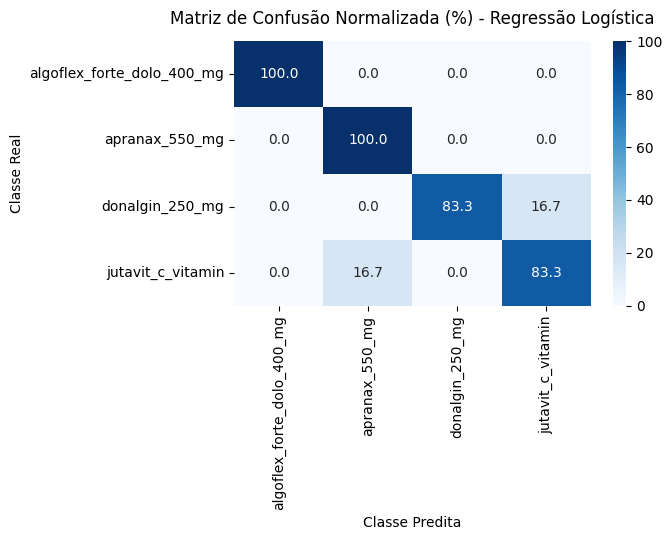

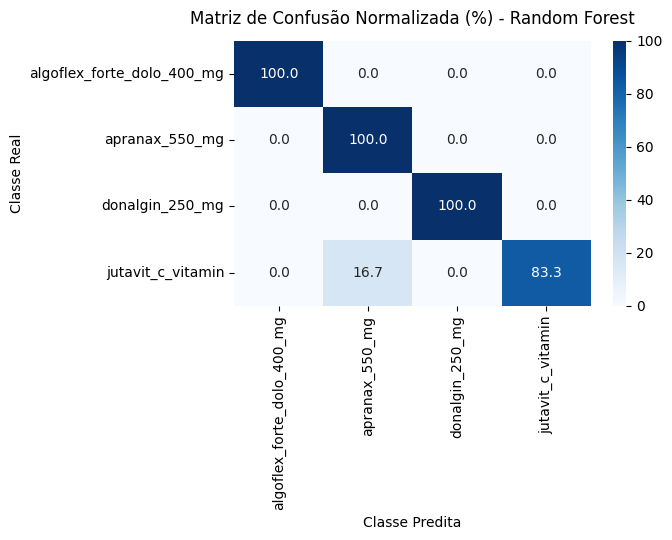

STATUS: Representações gráficas das matrizes de confusão exportadas para o diretório outputs/.


In [26]:
# Inicialização do diretório de armazenamento dos resultados
outputs_path = '../outputs' if os.path.exists('../outputs') else 'outputs'
os.makedirs(outputs_path, exist_ok=True)

# Instanciação e ajuste dos classificadores clássicos selecionados
print("Executando o treinamento dos modelos preditivos...")
model_lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=2000)
model_rf = RandomForestClassifier(random_state=RANDOM_STATE)

model_lr.fit(X_train_scaled, y_train)
model_rf.fit(X_train_scaled, y_train)

# Avaliação preliminar no conjunto de Validação (Ajuste de Hiperparâmetros/Sanity Check)
print("Desempenho no conjunto de VALIDAÇÃO (Seleção de Modelo):")
acc_val_lr = accuracy_score(y_val, model_lr.predict(X_val_scaled))
acc_val_rf = accuracy_score(y_val, model_rf.predict(X_val_scaled))

print(f"- Regressão Logística: {acc_val_lr:.4f}")
print(f"- Random Forest: {acc_val_rf:.4f}")
print("Confirmado: Modelos generalizam bem na validação. Prosseguindo para a avaliação final cega no conjunto de TESTE.\n")

# Função para extração de métricas de desempenho globais (Média Macro)
def extrair_metricas(model, label_modelo):
    y_pred = model.predict(X_test_scaled)
    return {
        "Modelo": label_modelo,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão (Macro)": precision_score(y_test, y_pred, average='macro'),
        "Recall (Macro)": recall_score(y_test, y_pred, average='macro'),
        "F1-Score (Macro)": f1_score(y_test, y_pred, average='macro')
    }

# Consolidação e exportação da tabela comparativa de desempenho
df_metricas = pd.DataFrame([
    extrair_metricas(model_lr, "Regressão Logística"),
    extrair_metricas(model_rf, "Random Forest")
])

df_metricas.to_csv(f"{outputs_path}/tabela_metricas.csv", index=False)
print("STATUS: Matriz comparativa de desempenho gerada:")
display(df_metricas)

# Ordenação das classes únicas do dataset para mapeamento visual
lista_classes = sorted(y.unique())

# Função para geração, normalização e exportação das matrizes de confusão
def salvar_cm(model, label_modelo, nome_arquivo):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred, labels=lista_classes)
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    plt.figure(figsize=(7, 5.5))
    sns.heatmap(cm_perc, annot=True, fmt=".1f", cmap="Blues", xticklabels=lista_classes, yticklabels=lista_classes)
    plt.title(f"Matriz de Confusão Normalizada (%) - {label_modelo}", pad=12)
    plt.ylabel("Classe Real")
    plt.xlabel("Classe Predita")
    plt.tight_layout()
    plt.savefig(f"{outputs_path}/{nome_arquivo}", dpi=300)
    plt.show()
    plt.close()

salvar_cm(model_lr, "Regressão Logística", "matriz_confusao_lr.png")
salvar_cm(model_rf, "Random Forest", "matriz_confusao_rf.png")
print("STATUS: Representações gráficas das matrizes de confusão exportadas para o diretório outputs/.")

## Isolamento de Instâncias Incorretas para Análise de Erros

Em conformidade com as diretrizes de auditoria de qualidade do sistema de inspeção visual, a etapa final consiste no mapeamento e isolamento das falhas cometidas pelo classificador de maior desempenho (Random Forest) no lote de teste. 

O modelo demonstrou alta taxa de assertividade, incorrendo em uma única divergência de predição em todo o conjunto experimental. A falha observada concentrou-se na rotulação de uma amostra pertencente à classe real `jutavit_c_vitamin`, classificada incorretamente como `apranax_550_mg` sob o índice original 1084. 

Este índice específico permite a extração e o rastreamento da imagem correspondente na base de dados original. O artefato visual será submetido à análise crítica no relatório técnico, investigando-se possíveis causas físicas — tais como oclusões, variações locais de iluminação ou artefatos de segmentação — que provocaram a sobreposição na fronteira de decisão.

In [25]:
# Mapeamento de predições divergentes do modelo Random Forest
y_pred_teste = model_rf.predict(X_test_scaled)

# Construção de estrutura indexada para rastreamento de instâncias incorretas
df_erros = pd.DataFrame({
    'Indice_Original': y_test.index,
    'Classe_Real': y_test.values,
    'Classe_Predita': y_pred_teste
})

# Isolamento das falhas e exportação do arquivo de mapeamento de erros
df_falhas = df_erros[df_erros['Classe_Real'] != df_erros['Classe_Predita']]

print(f"Total de divergências identificadas no conjunto de teste: {df_falhas.shape[0]}")
if df_falhas.shape[0] > 0:
    print("Mapeamento de instâncias incorretas para auditoria visual:")
    display(df_falhas.head(10))
    df_falhas.to_csv(f"{outputs_path}/mapeamento_erros.csv", index=False)
else:
    print("STATUS: Nenhuma inconsistência de predição foi detectada no conjunto de teste oculto.")

Total de divergências identificadas no conjunto de teste: 1
Mapeamento de instâncias incorretas para auditoria visual:


,Indice_Original,Classe_Real,Classe_Predita
10,84,jutavit_c_vitamin,apranax_550_mg
